# SER Experiment Result Statistics

Notebook này tổng hợp kết quả thực nghiệm đã chạy:

- LOSO 5 sessions cho Baseline, MAL, TIM.
- TIM temporal ablations trong `results/tim_ablations`.

Output phụ được lưu vào `reports/result_statistics/` để dùng trực tiếp cho báo cáo/paper.

In [31]:
from pathlib import Path
import json
import os
import re
import sys

os.environ.setdefault("MPLCONFIGDIR", str((Path.cwd() / ".matplotlib_cache").resolve()))

try:
    display
except NameError:
    def display(value):
        print(value)

import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

PROJECT_ROOT = Path("..").resolve() if Path.cwd().name in {"notebook", "notebooks"} else Path.cwd().resolve()
RESULTS_DIR = PROJECT_ROOT / "results"
REPORT_DIR = PROJECT_ROOT / "reports" / "result_statistics"
FIGURE_DIR = REPORT_DIR / "figures"
REPORT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

METRICS = ["WA", "UA", "WF1", "Macro-F1"]
LABEL_NAMES = ["angry", "happy", "neutral", "sad"]
print("PROJECT_ROOT =", PROJECT_ROOT)
print("REPORT_DIR   =", REPORT_DIR)


PROJECT_ROOT = /Users/ngocbao/Documents/Document/research/main/speech/exps/demo
REPORT_DIR   = /Users/ngocbao/Documents/Document/research/main/speech/exps/demo/reports/result_statistics


## Utility Functions

In [32]:
def read_json(path: Path) -> dict:
    return json.loads(path.read_text(encoding="utf-8"))


def percent(value):
    return 100.0 * float(value) if pd.notna(value) else np.nan


def format_mean_std(mean, std):
    return f"{percent(mean):.2f} ± {percent(std):.2f}"


def model_name_from_summary(path: Path, payload: dict) -> str:
    text = str(path)
    experiment = str(payload.get("trainer_module", ""))
    if "wavlm_baseline_loso" in text or experiment.endswith("train_wavlm_baseline"):
        return "Baseline"
    if "wavlm_mal_loso" in text or experiment.endswith("train_wavlm_mal"):
        return "MAL"
    if "wavlm_tim_loso" in text or experiment.endswith("train_wavlm_tim"):
        return "TIM"
    return path.parts[-4] if len(path.parts) >= 4 else path.stem


def ablation_name_from_path(path: Path) -> str:
    parts = path.parts
    if "tim_ablations" in parts:
        idx = parts.index("tim_ablations")
        return parts[idx + 1]
    return path.parent.name


def seed_from_path(path: Path) -> int | None:
    match = re.search(r"seed_(\d+)", str(path))
    return int(match.group(1)) if match else None


def rows_from_cross_session_summary(path: Path, family: str, name: str) -> tuple[list[dict], list[dict]]:
    payload = read_json(path)
    aggregate_rows = []
    fold_rows = []
    seed = seed_from_path(path)
    for metric in METRICS:
        item = payload["aggregate"][metric]
        aggregate_rows.append(
            {
                "family": family,
                "name": name,
                "seed": seed,
                "metric": metric,
                "mean": float(item["mean"]),
                "std": float(item["std"]),
                "n": int(item["n"]),
                "summary_path": str(path),
            }
        )
    for fold in payload.get("folds", []):
        for metric in METRICS:
            fold_rows.append(
                {
                    "family": family,
                    "name": name,
                    "seed": seed,
                    "test_session": int(fold["test_session"]),
                    "metric": metric,
                    "value": float(fold["metrics"][metric]),
                    "summary_path": str(path),
                }
            )
    return aggregate_rows, fold_rows

## Load LOSO Results

In [33]:
loso_summary_paths = sorted(
    path for path in RESULTS_DIR.glob("wavlm_*_loso/cross_session/*/cross_session_summary.json")
)
loso_aggregate_rows = []
loso_fold_rows = []
for path in loso_summary_paths:
    payload = read_json(path)
    model_name = model_name_from_summary(path, payload)
    aggregate, folds = rows_from_cross_session_summary(path, family="loso", name=model_name)
    loso_aggregate_rows.extend(aggregate)
    loso_fold_rows.extend(folds)

loso_aggregate = pd.DataFrame(loso_aggregate_rows)
loso_folds = pd.DataFrame(loso_fold_rows)

loso_aggregate.to_csv(REPORT_DIR / "loso_aggregate_long.csv", index=False)
loso_folds.to_csv(REPORT_DIR / "loso_folds_long.csv", index=False)

print("Found LOSO summaries:", len(loso_summary_paths))
display(loso_aggregate)

Found LOSO summaries: 3


,family,name,seed,metric,mean,std,n,summary_path
0,loso,Baseline,None,WA,0.494202,0.056098,5,/Users/ngocbao/Documents/Document/research/mai...
1,loso,Baseline,None,UA,0.417288,0.038252,5,/Users/ngocbao/Documents/Document/research/mai...
2,loso,Baseline,None,WF1,0.430841,0.053276,5,/Users/ngocbao/Documents/Document/research/mai...
3,loso,Baseline,None,Macro-F1,0.391701,0.035843,5,/Users/ngocbao/Documents/Document/research/mai...
4,loso,MAL,None,WA,0.647929,0.050129,5,/Users/ngocbao/Documents/Document/research/mai...
5,loso,MAL,None,UA,0.621557,0.047337,5,/Users/ngocbao/Documents/Document/research/mai...
6,loso,MAL,None,WF1,0.641164,0.049162,5,/Users/ngocbao/Documents/Document/research/mai...
7,loso,MAL,None,Macro-F1,0.616231,0.045131,5,/Users/ngocbao/Documents/Document/research/mai...
8,loso,TIM,None,WA,0.647940,0.066686,5,/Users/ngocbao/Documents/Document/research/mai...
9,loso,TIM,None,UA,0.631665,0.038511,5,/Users/ngocbao/Documents/Document/research/mai...


In [34]:
loso_table = (
    loso_aggregate.assign(mean_std=lambda df: [format_mean_std(m, s) for m, s in zip(df["mean"], df["std"])])
    .pivot(index="name", columns="metric", values="mean_std")
    .reindex(["Baseline", "MAL", "TIM"])
)
loso_table.to_csv(REPORT_DIR / "loso_summary_table.csv")
display(loso_table)

metric,Macro-F1,UA,WA,WF1
name,,,,
Baseline,39.17 ± 3.58,41.73 ± 3.83,49.42 ± 5.61,43.08 ± 5.33
MAL,61.62 ± 4.51,62.16 ± 4.73,64.79 ± 5.01,64.12 ± 4.92
TIM,61.95 ± 5.53,63.17 ± 3.85,64.79 ± 6.67,64.40 ± 6.65


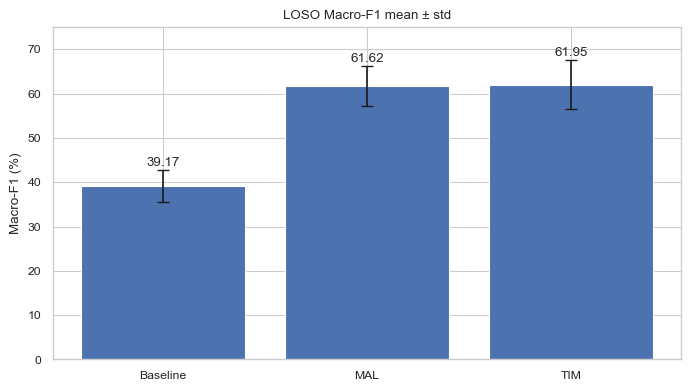

In [35]:
metric = "Macro-F1"
plot_df = loso_aggregate[loso_aggregate["metric"].eq(metric)].copy()
plot_df["mean_pct"] = plot_df["mean"].map(percent)
plot_df["std_pct"] = plot_df["std"].map(percent)

fig, ax = plt.subplots(figsize=(7, 4))
order = ["Baseline", "MAL", "TIM"]
plot_df = plot_df.set_index("name").loc[order].reset_index()
ax.bar(plot_df["name"], plot_df["mean_pct"], yerr=plot_df["std_pct"], capsize=4)
ax.set_ylabel(f"{metric} (%)")
ax.set_title("LOSO Macro-F1 mean ± std")
ax.set_ylim(0, max(75, plot_df["mean_pct"].max() + plot_df["std_pct"].max() + 5))
for index, row in plot_df.iterrows():
    ax.text(index, row["mean_pct"] + row["std_pct"] + 1, f"{row['mean_pct']:.2f}", ha="center")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "loso_macro_f1_bar.png", dpi=180)
plt.show()

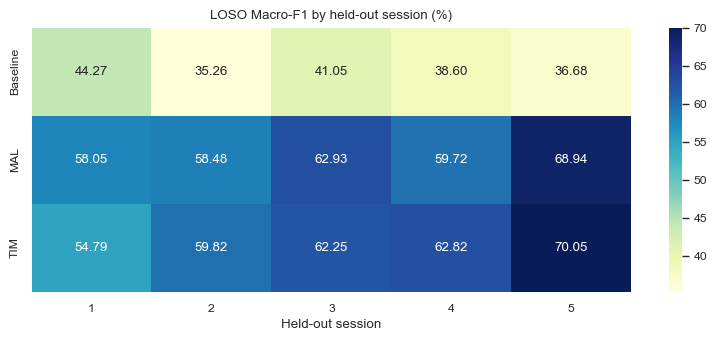

test_session,1,2,3,4,5
name,,,,,
Baseline,44.267771,35.255467,41.051758,38.597235,36.678481
MAL,58.052473,58.478186,62.928263,59.719028,68.937637
TIM,54.791075,59.822024,62.247310,62.821593,70.049786


In [36]:
fold_macro = loso_folds[loso_folds["metric"].eq("Macro-F1")].copy()
fold_pivot = fold_macro.pivot(index="name", columns="test_session", values="value").reindex(["Baseline", "MAL", "TIM"])
fold_pivot_pct = fold_pivot * 100.0
fold_pivot_pct.to_csv(REPORT_DIR / "loso_macro_f1_by_session.csv")

fig, ax = plt.subplots(figsize=(8, 3.5))
sns.heatmap(fold_pivot_pct, annot=True, fmt=".2f", cmap="YlGnBu", ax=ax)
ax.set_title("LOSO Macro-F1 by held-out session (%)")
ax.set_xlabel("Held-out session")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "loso_macro_f1_session_heatmap.png", dpi=180)
plt.show()

display(fold_pivot_pct)

## Load TIM Ablation Results

In [37]:
ablation_summary_paths = sorted((RESULTS_DIR / "tim_ablations").glob("*/seed_*/run_*/cross_session_summary.json"))
ablation_aggregate_rows = []
ablation_fold_rows = []

for path in ablation_summary_paths:
    name = ablation_name_from_path(path)
    aggregate, folds = rows_from_cross_session_summary(path, family="tim_ablation", name=name)
    ablation_aggregate_rows.extend(aggregate)
    ablation_fold_rows.extend(folds)

# Add full TIM LOSO as the reference row for comparison.
tim_paths = [path for path in loso_summary_paths if "wavlm_tim_loso" in str(path)]
for path in tim_paths:
    aggregate, folds = rows_from_cross_session_summary(path, family="tim_ablation", name="tim_full")
    ablation_aggregate_rows.extend(aggregate)
    ablation_fold_rows.extend(folds)

ablation_aggregate = pd.DataFrame(ablation_aggregate_rows)
ablation_folds = pd.DataFrame(ablation_fold_rows)

ablation_aggregate.to_csv(REPORT_DIR / "tim_ablation_aggregate_long.csv", index=False)
ablation_folds.to_csv(REPORT_DIR / "tim_ablation_folds_long.csv", index=False)

print("Found TIM ablation summaries:", len(ablation_summary_paths))
display(ablation_aggregate.sort_values(["metric", "mean"], ascending=[True, False]).head(20))

Found TIM ablation summaries: 8


,family,name,seed,metric,mean,std,n,summary_path
31,tim_ablation,tim_zero,42.0,Macro-F1,0.629579,0.047411,5,/Users/ngocbao/Documents/Document/research/mai...
11,tim_ablation,tim_no_overlap,42.0,Macro-F1,0.624956,0.056242,5,/Users/ngocbao/Documents/Document/research/mai...
3,tim_ablation,tim_no_duration,42.0,Macro-F1,0.624257,0.040788,5,/Users/ngocbao/Documents/Document/research/mai...
35,tim_ablation,tim_full,NaN,Macro-F1,0.619464,0.055280,5,/Users/ngocbao/Documents/Document/research/mai...
15,tim_ablation,tim_no_speaker_switch,42.0,Macro-F1,0.613219,0.059148,5,/Users/ngocbao/Documents/Document/research/mai...
7,tim_ablation,tim_no_gap,42.0,Macro-F1,0.612543,0.057697,5,/Users/ngocbao/Documents/Document/research/mai...
19,tim_ablation,tim_no_turn_position,42.0,Macro-F1,0.607972,0.067560,5,/Users/ngocbao/Documents/Document/research/mai...
27,tim_ablation,tim_shuffled,42.0,Macro-F1,0.605509,0.047380,5,/Users/ngocbao/Documents/Document/research/mai...
23,tim_ablation,tim_overlap_only,42.0,Macro-F1,0.602002,0.085693,5,/Users/ngocbao/Documents/Document/research/mai...
29,tim_ablation,tim_zero,42.0,UA,0.642628,0.042292,5,/Users/ngocbao/Documents/Document/research/mai...


In [38]:
ablation_table = (
    ablation_aggregate.assign(mean_std=lambda df: [format_mean_std(m, s) for m, s in zip(df["mean"], df["std"])])
    .pivot(index="name", columns="metric", values="mean_std")
)
rank_order = (
    ablation_aggregate[ablation_aggregate["metric"].eq("Macro-F1")]
    .sort_values("mean", ascending=False)["name"]
    .tolist()
)
ablation_table = ablation_table.loc[rank_order]
ablation_table.to_csv(REPORT_DIR / "tim_ablation_summary_table.csv")
display(ablation_table)

metric,Macro-F1,UA,WA,WF1
name,,,,
tim_zero,62.96 ± 4.74,64.26 ± 4.23,65.71 ± 5.52,65.40 ± 5.62
tim_no_overlap,62.50 ± 5.62,64.07 ± 4.50,65.27 ± 6.63,65.04 ± 6.59
tim_no_duration,62.43 ± 4.08,63.33 ± 3.35,65.74 ± 4.85,65.16 ± 4.74
tim_full,61.95 ± 5.53,63.17 ± 3.85,64.79 ± 6.67,64.40 ± 6.65
tim_no_speaker_switch,61.32 ± 5.91,62.72 ± 4.41,64.39 ± 7.06,63.79 ± 7.10
tim_no_gap,61.25 ± 5.77,62.61 ± 4.31,64.51 ± 6.31,63.97 ± 6.59
tim_no_turn_position,60.80 ± 6.76,61.79 ± 5.11,63.90 ± 7.80,63.31 ± 7.79
tim_shuffled,60.55 ± 4.74,60.85 ± 3.62,63.72 ± 6.69,62.99 ± 6.10
tim_overlap_only,60.20 ± 8.57,61.74 ± 5.42,62.94 ± 8.95,62.37 ± 9.91


In [39]:
macro = ablation_aggregate[ablation_aggregate["metric"].eq("Macro-F1")].copy()
macro["mean_pct"] = macro["mean"].map(percent)
macro["std_pct"] = macro["std"].map(percent)
macro = macro.sort_values("mean_pct", ascending=False)

tim_full_mean = float(macro.loc[macro["name"].eq("tim_full"), "mean"].iloc[0]) if macro["name"].eq("tim_full").any() else np.nan
tim_zero_mean = float(macro.loc[macro["name"].eq("tim_zero"), "mean"].iloc[0]) if macro["name"].eq("tim_zero").any() else np.nan
macro["delta_vs_tim_full_pp"] = (macro["mean"] - tim_full_mean) * 100.0
macro["delta_vs_tim_zero_pp"] = (macro["mean"] - tim_zero_mean) * 100.0
macro.to_csv(REPORT_DIR / "tim_ablation_macro_f1_ranking.csv", index=False)

display(macro[["name", "mean_pct", "std_pct", "delta_vs_tim_full_pp", "delta_vs_tim_zero_pp", "n", "summary_path"]])

,name,mean_pct,std_pct,delta_vs_tim_full_pp,delta_vs_tim_zero_pp,n,summary_path
31,tim_zero,62.957871,4.741143,1.011514,0.000000,5,/Users/ngocbao/Documents/Document/research/mai...
11,tim_no_overlap,62.495626,5.624169,0.549269,-0.462245,5,/Users/ngocbao/Documents/Document/research/mai...
3,tim_no_duration,62.425705,4.078797,0.479348,-0.532166,5,/Users/ngocbao/Documents/Document/research/mai...
35,tim_full,61.946358,5.527952,0.000000,-1.011514,5,/Users/ngocbao/Documents/Document/research/mai...
15,tim_no_speaker_switch,61.321863,5.914850,-0.624494,-1.636008,5,/Users/ngocbao/Documents/Document/research/mai...
7,tim_no_gap,61.254263,5.769712,-0.692095,-1.703609,5,/Users/ngocbao/Documents/Document/research/mai...
19,tim_no_turn_position,60.797240,6.755963,-1.149117,-2.160631,5,/Users/ngocbao/Documents/Document/research/mai...
27,tim_shuffled,60.550877,4.737971,-1.395481,-2.406994,5,/Users/ngocbao/Documents/Document/research/mai...
23,tim_overlap_only,60.200210,8.569327,-1.746147,-2.757661,5,/Users/ngocbao/Documents/Document/research/mai...


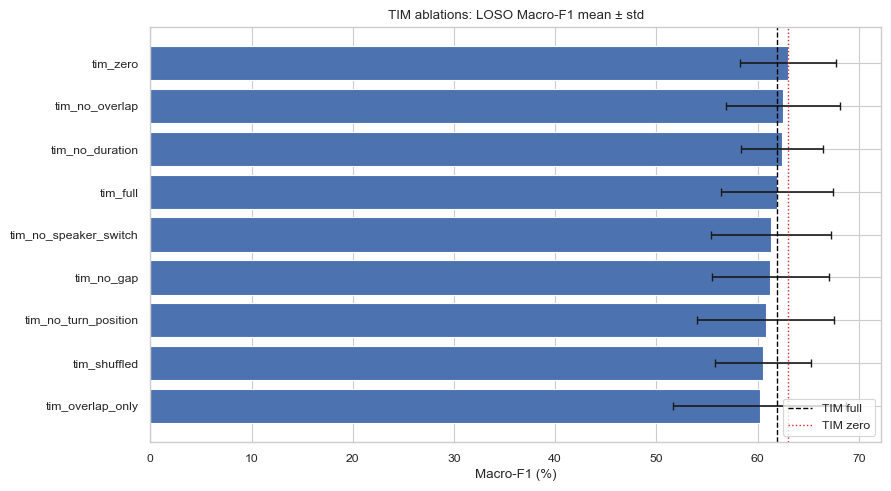

In [40]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(macro["name"], macro["mean_pct"], xerr=macro["std_pct"], capsize=3)
ax.axvline(percent(tim_full_mean), color="black", linestyle="--", linewidth=1, label="TIM full")
if pd.notna(tim_zero_mean):
    ax.axvline(percent(tim_zero_mean), color="tab:red", linestyle=":", linewidth=1, label="TIM zero")
ax.invert_yaxis()
ax.set_xlabel("Macro-F1 (%)")
ax.set_title("TIM ablations: LOSO Macro-F1 mean ± std")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "tim_ablation_macro_f1_bar.png", dpi=180)
plt.show()

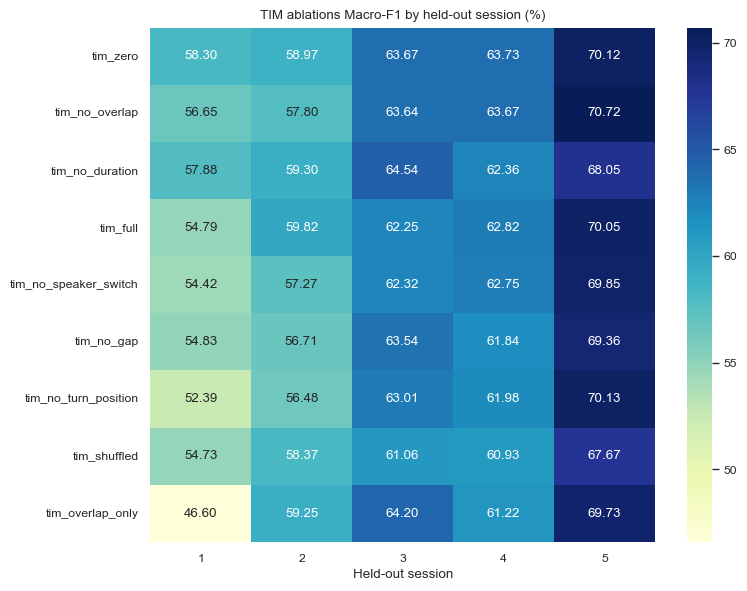

test_session,1,2,3,4,5
name,,,,,
tim_zero,58.302855,58.972382,63.666660,63.729831,70.117629
tim_no_overlap,56.646589,57.803862,63.635316,63.673978,70.718388
tim_no_duration,57.881167,59.296233,64.543788,62.359424,68.047913
tim_full,54.791075,59.822024,62.247310,62.821593,70.049786
tim_no_speaker_switch,54.415067,57.272545,62.318071,62.748745,69.854890
tim_no_gap,54.830784,56.708214,63.535558,61.837815,69.358942
tim_no_turn_position,52.393106,56.481740,63.005813,61.978452,70.127091
tim_shuffled,54.725956,58.370172,61.055299,60.931034,67.671924
tim_overlap_only,46.601228,59.250177,64.197620,61.218602,69.733423


In [41]:
ablation_macro_folds = ablation_folds[ablation_folds["metric"].eq("Macro-F1")].copy()
ablation_fold_pivot = ablation_macro_folds.pivot_table(index="name", columns="test_session", values="value", aggfunc="mean")
ablation_fold_pivot = ablation_fold_pivot.loc[rank_order]
ablation_fold_pivot_pct = ablation_fold_pivot * 100.0
ablation_fold_pivot_pct.to_csv(REPORT_DIR / "tim_ablation_macro_f1_by_session.csv")

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(ablation_fold_pivot_pct, annot=True, fmt=".2f", cmap="YlGnBu", ax=ax)
ax.set_title("TIM ablations Macro-F1 by held-out session (%)")
ax.set_xlabel("Held-out session")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "tim_ablation_macro_f1_session_heatmap.png", dpi=180)
plt.show()

display(ablation_fold_pivot_pct)

## Automatic Notes

In [42]:
best = macro.iloc[0]
tim_full = macro[macro["name"].eq("tim_full")].iloc[0]
notes = []
notes.append(f"Best ablation by Macro-F1: {best['name']} = {best['mean_pct']:.2f} ± {best['std_pct']:.2f}.")
notes.append(f"TIM full Macro-F1: {percent(tim_full['mean']):.2f} ± {percent(tim_full['std']):.2f}.")
if macro["name"].eq("tim_shuffled").any():
    shuffled = macro[macro["name"].eq("tim_shuffled")].iloc[0]
    notes.append(f"TIM shuffled delta vs TIM full: {(shuffled['mean'] - tim_full['mean']) * 100:.2f} pp.")
if macro["name"].eq("tim_zero").any():
    zero = macro[macro["name"].eq("tim_zero")].iloc[0]
    notes.append(f"TIM zero delta vs TIM full: {(zero['mean'] - tim_full['mean']) * 100:.2f} pp.")

notes_text = "\n".join(f"- {line}" for line in notes)
(REPORT_DIR / "result_statistics_notes.md").write_text("# Result Statistics Notes\n\n" + notes_text + "\n", encoding="utf-8")
print(notes_text)

- Best ablation by Macro-F1: tim_zero = 62.96 ± 4.74.
- TIM full Macro-F1: 61.95 ± 5.53.
- TIM shuffled delta vs TIM full: -1.40 pp.
- TIM zero delta vs TIM full: 1.01 pp.


## Error Analysis: Baseline vs MAL vs TIM

Phần này tập trung vào từng utterance trong 5-fold LOSO:

- Baseline sai ở emotion nào và nhầm sang emotion nào.
- MAL sửa được bao nhiêu lỗi của Baseline, đồng thời làm hỏng bao nhiêu case Baseline đúng.
- TIM sửa được bao nhiêu lỗi của MAL/Baseline, đồng thời làm hỏng bao nhiêu case MAL/Baseline đúng.
- Các cải thiện/suy giảm nằm ở nhóm temporal nào: overlap, gap, duration, speaker switch, vị trí turn.


In [43]:
ERROR_REPORT_DIR = REPORT_DIR / 'error_analysis'
ERROR_FIGURE_DIR = ERROR_REPORT_DIR / 'figures'
ERROR_REPORT_DIR.mkdir(parents=True, exist_ok=True)
ERROR_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

MODEL_RESULT_DIRS = {
    'Baseline': RESULTS_DIR / 'wavlm_baseline_loso',
    'MAL': RESULTS_DIR / 'wavlm_mal_loso',
    'TIM': RESULTS_DIR / 'wavlm_tim_loso',
}

TEMPORAL_COLUMNS = [
    'duration', 'gap_prev', 'overlap_prev', 'overlap_ratio', 'is_overlap', 'is_interrupting_prev',
    'speaker_switch', 'same_speaker', 'turn_index_norm', 'prev_gap_abs', 'short_response', 'long_pause',
    'speaker_prev_overlap_rate', 'speaker_prev_mean_gap', 'speaker_prev_mean_duration', 'speaker_prev_turn_count_norm',
]

PROB_COLUMNS = ['prob_angry', 'prob_happy', 'prob_neutral', 'prob_sad']


def latest_cross_session_run(model_dir: Path) -> Path:
    runs = sorted((model_dir / 'cross_session').glob('run_*'))
    if not runs:
        raise FileNotFoundError(f'No cross_session run found under {model_dir}')
    return runs[-1]


def load_model_predictions(model_name: str, model_dir: Path) -> pd.DataFrame:
    run_dir = latest_cross_session_run(model_dir)
    frames = []
    for pred_path in sorted(run_dir.glob('test_Ses*/predictions.csv')):
        frame = pd.read_csv(pred_path)
        match = re.search(r'test_Ses(\d+)', str(pred_path))
        test_session = int(match.group(1)) if match else np.nan
        frame['test_session'] = test_session
        frame['model'] = model_name
        frame['source_path'] = str(pred_path)
        frames.append(frame)
    if not frames:
        raise FileNotFoundError(f'No predictions.csv files found under {run_dir}')
    out = pd.concat(frames, ignore_index=True)
    out['correct'] = out['gold_label'].eq(out['pred_label'])
    out['confidence'] = out[PROB_COLUMNS].max(axis=1)
    return out

pred_long = pd.concat(
    [load_model_predictions(name, path) for name, path in MODEL_RESULT_DIRS.items()],
    ignore_index=True,
)
pred_long.to_csv(ERROR_REPORT_DIR / 'loso_predictions_long.csv', index=False)

print('Loaded predictions:', pred_long.shape)
display(pred_long.groupby(['model', 'test_session'])['correct'].agg(['count', 'mean']).assign(acc_pct=lambda x: x['mean'] * 100).round(3))


Loaded predictions: (22587, 32)


count   mean  acc_pct
model    test_session                       
Baseline 1              1403  0.503   50.321
         2              1374  0.436   43.595
         3              1564  0.520   52.046
         4              1538  0.570   56.957
         5              1650  0.442   44.182
MAL      1              1403  0.590   59.016
         2              1374  0.601   60.116
         3              1564  0.660   65.985
         4              1538  0.687   68.726
         5              1650  0.701   70.121
TIM      1              1403  0.559   55.880
         2              1374  0.619   61.936
         3              1564  0.633   63.299
         4              1538  0.715   71.521
         5              1650  0.713   71.333

In [44]:
def model_slice(frame: pd.DataFrame, model_name: str) -> pd.DataFrame:
    cols = [
        'dialogue_id', 'utterance_id', 'speaker_id', 'start_time', 'end_time', 'test_session',
        'gold_label', 'pred_label', 'correct', 'confidence', *PROB_COLUMNS,
    ]
    keep = [col for col in cols if col in frame.columns]
    sub = frame[frame['model'].eq(model_name)][keep].copy()
    rename = {
        'pred_label': f'{model_name}_pred',
        'correct': f'{model_name}_correct',
        'confidence': f'{model_name}_confidence',
    }
    rename.update({col: f'{model_name}_{col}' for col in PROB_COLUMNS if col in sub.columns})
    return sub.rename(columns=rename)

wide = model_slice(pred_long, 'Baseline')
for model_name in ['MAL', 'TIM']:
    extra = model_slice(pred_long, model_name).drop(columns=['gold_label'], errors='ignore')
    wide = wide.merge(extra, on=['dialogue_id', 'utterance_id', 'speaker_id', 'start_time', 'end_time', 'test_session'], how='inner')

# Attach temporal features from TIM predictions. Baseline/MAL predictions do not store them.
tim_temporal = pred_long[pred_long['model'].eq('TIM')][['utterance_id', *[c for c in TEMPORAL_COLUMNS if c in pred_long.columns]]].drop_duplicates('utterance_id')
wide = wide.merge(tim_temporal, on='utterance_id', how='left')

wide['session'] = wide['test_session'].map(lambda x: f'Ses{int(x):02d}')
wide['duration_bin'] = pd.cut(wide['duration'], bins=[-0.001, 2.0, 5.0, np.inf], labels=['short_<=2s', 'mid_2-5s', 'long_>5s'])
wide['gap_bin'] = pd.cut(wide['gap_prev'], bins=[-np.inf, -0.001, 0.3, 1.0, np.inf], labels=['overlap_gap<0', 'short_0-0.3s', 'mid_0.3-1s', 'long_>1s'])
wide['turn_bin'] = pd.cut(wide['turn_index_norm'], bins=[-0.001, 0.33, 0.66, 1.001], labels=['early', 'middle', 'late'])
wide['overlap_bucket'] = np.where(wide['is_overlap'].fillna(0).astype(float) > 0, 'overlap', 'no_overlap')
wide['speaker_switch_bucket'] = np.where(wide['speaker_switch'].fillna(0).astype(float) > 0, 'speaker_switch', 'same_or_first_speaker')

for model_name in ['Baseline', 'MAL', 'TIM']:
    wide[f'{model_name}_wrong'] = ~wide[f'{model_name}_correct']

wide.to_csv(ERROR_REPORT_DIR / 'baseline_mal_tim_paired_predictions.csv', index=False)
print('Paired utterances:', len(wide))
display(wide.head())


Paired utterances: 7529


,dialogue_id,utterance_id,speaker_id,start_time,end_time,test_session,gold_label,Baseline_pred,Baseline_correct,Baseline_confidence,Baseline_prob_angry,Baseline_prob_happy,Baseline_prob_neutral,Baseline_prob_sad,MAL_pred,MAL_correct,MAL_confidence,MAL_prob_angry,MAL_prob_happy,MAL_prob_neutral,MAL_prob_sad,TIM_pred,TIM_correct,TIM_confidence,TIM_prob_angry,TIM_prob_happy,TIM_prob_neutral,TIM_prob_sad,duration,gap_prev,overlap_prev,overlap_ratio,is_overlap,is_interrupting_prev,speaker_switch,same_speaker,turn_index_norm,prev_gap_abs,short_response,long_pause,speaker_prev_overlap_rate,speaker_prev_mean_gap,speaker_prev_mean_duration,speaker_prev_turn_count_norm,session,duration_bin,gap_bin,turn_bin,overlap_bucket,speaker_switch_bucket,Baseline_wrong,MAL_wrong,TIM_wrong
0,Ses01F_impro01,Ses01F_impro01_F000,Ses01_F,6.2901,8.2357,1,neutral,neutral,True,0.272679,0.267607,0.194903,0.272679,0.264811,angry,False,0.294042,0.294042,0.218498,0.219231,0.268229,sad,False,0.440664,0.124624,0.189761,0.244951,0.440664,1.9456,0.0000,0.0000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0000,0.0,0.0,0.0,0.0000,0.00000,0.000000,Ses01,short_<=2s,short_0-0.3s,early,no_overlap,same_or_first_speaker,False,True,True
1,Ses01F_impro01,Ses01F_impro01_M000,Ses01_M,7.5712,10.4750,1,angry,sad,False,0.304189,0.180414,0.226371,0.289027,0.304189,neutral,False,0.722545,0.012828,0.102481,0.722545,0.162145,neutral,False,0.720353,0.014859,0.131229,0.720353,0.133559,2.9038,-0.6645,0.6645,0.228838,1.0,1.0,1.0,0.0,0.008929,0.6645,0.0,0.0,0.0,0.0000,0.00000,0.000000,Ses01,mid_2-5s,overlap_gap<0,early,overlap,speaker_switch,True,True,True
2,Ses01F_impro01,Ses01F_impro01_F001,Ses01_F,10.0100,11.3925,1,neutral,neutral,True,0.317292,0.290598,0.230399,0.317292,0.161711,happy,False,0.785060,0.022146,0.785060,0.101345,0.091449,happy,False,0.681216,0.008656,0.681216,0.141330,0.168798,1.3825,-0.4650,0.4650,0.336347,1.0,1.0,1.0,0.0,0.017857,0.4650,0.0,0.0,0.0,0.0000,1.94560,0.008929,Ses01,short_<=2s,overlap_gap<0,early,overlap,speaker_switch,False,True,True
3,Ses01F_impro01,Ses01F_impro01_M001,Ses01_M,10.9266,14.6649,1,angry,sad,False,0.648880,0.066066,0.102183,0.182871,0.648880,sad,False,0.570743,0.001012,0.208780,0.219465,0.570743,sad,False,0.693500,0.000800,0.152865,0.152835,0.693500,3.7383,-0.4659,0.4659,0.124629,1.0,1.0,1.0,0.0,0.026786,0.4659,0.0,0.0,1.0,-0.6645,2.90380,0.008929,Ses01,mid_2-5s,overlap_gap<0,early,overlap,speaker_switch,True,True,True
4,Ses01F_impro01,Ses01F_impro01_F002,Ses01_F,14.8872,18.0175,1,neutral,sad,False,0.410185,0.240880,0.202732,0.146203,0.410185,sad,False,0.558668,0.004375,0.378573,0.058384,0.558668,sad,False,0.436082,0.008559,0.428127,0.127231,0.436082,3.1303,0.2223,0.0000,0.000000,0.0,0.0,1.0,0.0,0.035714,0.2223,1.0,0.0,0.5,-0.2325,1.66405,0.017857,Ses01,mid_2-5s,short_0-0.3s,early,no_overlap,speaker_switch,True,True,True


### Overall Fix/Break Counts

`fix` nghĩa là model sau đúng trong khi model trước sai. `break` nghĩa là model sau sai trong khi model trước đúng.


In [45]:
def pair_status(frame: pd.DataFrame, left: str, right: str) -> pd.Series:
    left_ok = frame[f'{left}_correct']
    right_ok = frame[f'{right}_correct']
    status = np.select(
        [left_ok & right_ok, ~left_ok & right_ok, left_ok & ~right_ok, ~left_ok & ~right_ok],
        ['both_correct', f'{right}_fixes_{left}', f'{right}_breaks_{left}', 'both_wrong'],
        default='unknown',
    )
    return pd.Series(status, index=frame.index)

wide['MAL_vs_Baseline'] = pair_status(wide, 'Baseline', 'MAL')
wide['TIM_vs_MAL'] = pair_status(wide, 'MAL', 'TIM')
wide['TIM_vs_Baseline'] = pair_status(wide, 'Baseline', 'TIM')

pair_summary_rows = []
for pair_col in ['MAL_vs_Baseline', 'TIM_vs_MAL', 'TIM_vs_Baseline']:
    counts = wide[pair_col].value_counts().rename_axis('status').reset_index(name='count')
    counts['pair'] = pair_col
    counts['ratio_pct'] = counts['count'] / len(wide) * 100
    pair_summary_rows.append(counts)
pair_summary = pd.concat(pair_summary_rows, ignore_index=True)[['pair', 'status', 'count', 'ratio_pct']]
pair_summary.to_csv(ERROR_REPORT_DIR / 'pair_fix_break_summary.csv', index=False)
display(pair_summary.sort_values(['pair', 'status']).round(3))


,pair,status,count,ratio_pct
3,MAL_vs_Baseline,MAL_breaks_Baseline,757,10.054
1,MAL_vs_Baseline,MAL_fixes_Baseline,1933,25.674
0,MAL_vs_Baseline,both_correct,2967,39.408
2,MAL_vs_Baseline,both_wrong,1872,24.864
11,TIM_vs_Baseline,TIM_breaks_Baseline,847,11.250
9,TIM_vs_Baseline,TIM_fixes_Baseline,2025,26.896
8,TIM_vs_Baseline,both_correct,2877,38.212
10,TIM_vs_Baseline,both_wrong,1780,23.642
7,TIM_vs_MAL,TIM_breaks_MAL,514,6.827
6,TIM_vs_MAL,TIM_fixes_MAL,516,6.853


In [46]:
model_accuracy = (
    wide.melt(
        id_vars=['utterance_id', 'gold_label', 'session'],
        value_vars=['Baseline_correct', 'MAL_correct', 'TIM_correct'],
        var_name='model', value_name='correct',
    )
    .assign(model=lambda df: df['model'].str.replace('_correct', '', regex=False))
    .groupby('model')['correct']
    .agg(['count', 'mean'])
    .reset_index()
)
model_accuracy['accuracy_pct'] = model_accuracy['mean'] * 100
model_accuracy.to_csv(ERROR_REPORT_DIR / 'model_accuracy_from_paired_predictions.csv', index=False)
display(model_accuracy.round(3))


,model,count,mean,accuracy_pct
0,Baseline,7529,0.495,49.462
1,MAL,7529,0.651,65.082
2,TIM,7529,0.651,65.108


### Where Each Model Is Wrong

Các bảng này cho thấy mỗi model hay nhầm class nào sang class nào. Sau đó là delta theo class để xem MAL/TIM cải thiện hoặc làm giảm class nào.


In [47]:
def confusion_long(frame: pd.DataFrame, model_name: str) -> pd.DataFrame:
    table = pd.crosstab(frame['gold_label'], frame[f'{model_name}_pred'])
    table = table.reindex(index=LABEL_NAMES, columns=LABEL_NAMES, fill_value=0)
    long = table.stack().rename('count').reset_index().rename(columns={'gold_label': 'gold', f'{model_name}_pred': 'pred'})
    long['model'] = model_name
    return long

confusion_all = pd.concat([confusion_long(wide, model) for model in ['Baseline', 'MAL', 'TIM']], ignore_index=True)
confusion_all.to_csv(ERROR_REPORT_DIR / 'confusion_counts_long.csv', index=False)

error_confusions = confusion_all[confusion_all['gold'].ne(confusion_all['pred'])].sort_values(['model', 'count'], ascending=[True, False])
error_confusions.to_csv(ERROR_REPORT_DIR / 'top_error_confusions.csv', index=False)
display(error_confusions.groupby('model').head(8))


,gold,pred,count,model
4,happy,angry,1283,Baseline
8,neutral,angry,1031,Baseline
12,sad,angry,357,Baseline
14,sad,neutral,270,Baseline
11,neutral,sad,195,Baseline
6,happy,neutral,177,Baseline
2,angry,neutral,165,Baseline
3,angry,sad,112,Baseline
24,neutral,angry,390,MAL
18,angry,neutral,351,MAL


In [48]:
per_class = []
for model_name in ['Baseline', 'MAL', 'TIM']:
    for label in LABEL_NAMES:
        mask = wide['gold_label'].eq(label)
        total = int(mask.sum())
        correct = int((mask & wide[f'{model_name}_correct']).sum())
        per_class.append({
            'model': model_name,
            'gold_label': label,
            'total': total,
            'correct': correct,
            'wrong': total - correct,
            'recall_pct': correct / total * 100 if total else np.nan,
        })
per_class = pd.DataFrame(per_class)
per_class_pivot = per_class.pivot(index='gold_label', columns='model', values='recall_pct').reindex(LABEL_NAMES)
per_class_pivot['MAL_minus_Baseline_pp'] = per_class_pivot['MAL'] - per_class_pivot['Baseline']
per_class_pivot['TIM_minus_MAL_pp'] = per_class_pivot['TIM'] - per_class_pivot['MAL']
per_class_pivot['TIM_minus_Baseline_pp'] = per_class_pivot['TIM'] - per_class_pivot['Baseline']
per_class.to_csv(ERROR_REPORT_DIR / 'per_class_recall_long.csv', index=False)
per_class_pivot.to_csv(ERROR_REPORT_DIR / 'per_class_recall_delta.csv')
display(per_class_pivot.round(2))


model,Baseline,MAL,TIM,MAL_minus_Baseline_pp,TIM_minus_MAL_pp,TIM_minus_Baseline_pp
gold_label,,,,,,
angry,89.51,74.61,71.60,-14.90,-3.01,-17.91
happy,9.87,66.95,71.54,57.09,4.59,61.68
neutral,25.53,45.14,46.96,19.61,1.81,21.43
sad,41.99,67.44,65.66,25.44,-1.78,23.67


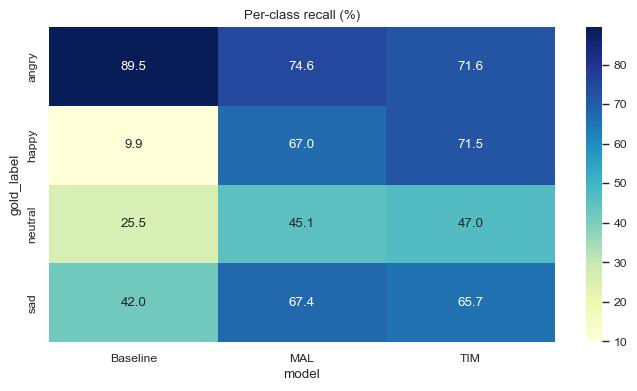

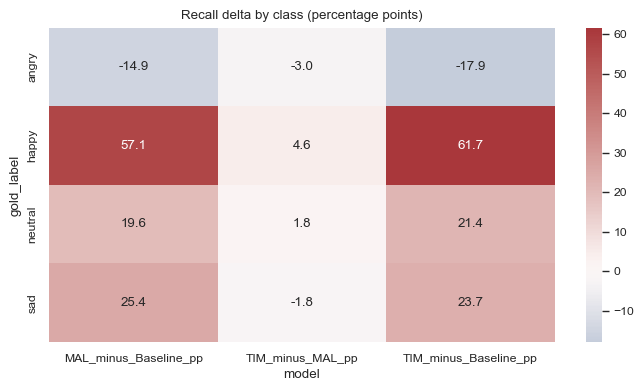

In [49]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(per_class_pivot[['Baseline', 'MAL', 'TIM']], annot=True, fmt='.1f', cmap='YlGnBu', ax=ax)
ax.set_title('Per-class recall (%)')
fig.tight_layout()
fig.savefig(ERROR_FIGURE_DIR / 'per_class_recall_heatmap.png', dpi=180)
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(per_class_pivot[['MAL_minus_Baseline_pp', 'TIM_minus_MAL_pp', 'TIM_minus_Baseline_pp']], annot=True, fmt='.1f', center=0, cmap='vlag', ax=ax)
ax.set_title('Recall delta by class (percentage points)')
fig.tight_layout()
fig.savefig(ERROR_FIGURE_DIR / 'per_class_recall_delta_heatmap.png', dpi=180)
plt.show()


### Which Errors MAL/TIM Fix

Các bảng dưới gom các case fix/break theo gold emotion và theo cặp nhầm `gold -> pred_before/pred_after`. Đây là phần quan trọng để viết phân tích định tính.


In [50]:
def fix_break_by_gold(frame: pd.DataFrame, pair_col: str) -> pd.DataFrame:
    out = (
        frame.groupby(['gold_label', pair_col])
        .size()
        .rename('count')
        .reset_index()
        .rename(columns={pair_col: 'status'})
    )
    out['pair'] = pair_col
    return out

fix_break_gold = pd.concat(
    [fix_break_by_gold(wide, pair_col) for pair_col in ['MAL_vs_Baseline', 'TIM_vs_MAL', 'TIM_vs_Baseline']],
    ignore_index=True,
)
fix_break_gold.to_csv(ERROR_REPORT_DIR / 'fix_break_by_gold_label.csv', index=False)
display(fix_break_gold.pivot_table(index=['pair', 'gold_label'], columns='status', values='count', fill_value=0))


status                      MAL_breaks_Baseline  MAL_fixes_Baseline  TIM_breaks_Baseline  TIM_breaks_MAL  TIM_fixes_Baseline  TIM_fixes_MAL  both_correct  \
pair            gold_label                                                                                                                                  
MAL_vs_Baseline angry                     535.0                95.0                  0.0             0.0                 0.0            0.0        2109.0   
                happy                      13.0              1008.0                  0.0             0.0                 0.0            0.0         159.0   
                neutral                   159.0               494.0                  0.0             0.0                 0.0            0.0         277.0   
                sad                        50.0               336.0                  0.0             0.0                 0.0            0.0         422.0   
TIM_vs_Baseline angry                       0.0                 0.0                612.0             0.0                83.0            0.0        2032.0   
                happy                       0.0                 0.0                 10.0             0.0              1085.0            0.0         162.0   
                neutral                     0.0                 0.0                159.0             0.0               525.0            0.0         277.0   
                sad                         0.0                 0.0                 66.0             0.0               332.0            0.0         406.0   
TIM_vs_MAL      angry                       0.0                 0.0                  0.0           203.0                 0.0          114.0        2001.0   
                happy                       0.0                 0.0                  0.0            94.0                 0.0          174.0        1073.0   
                neutral                     0.0                 0.0                  0.0           131.0                 0.0          162.0         640.0   
                sad                         0.0                 0.0                  0.0            86.0                 0.0           66.0         672.0   

status                      both_wrong  
pair            gold_label              
MAL_vs_Baseline angry            215.0  
                happy            563.0  
                neutral          778.0  
                sad              316.0  
TIM_vs_Baseline angry            227.0  
                happy            486.0  
                neutral          747.0  
                sad              320.0  
TIM_vs_MAL      angry            636.0  
                happy            402.0  
                neutral          775.0  
                sad              300.0

In [51]:
def transition_fix_break(frame: pd.DataFrame, left: str, right: str) -> pd.DataFrame:
    status_col = f'{right}_vs_{left}' if f'{right}_vs_{left}' in frame.columns else None
    if status_col is None:
        status_col = 'tmp_status'
        tmp = frame.copy()
        tmp[status_col] = pair_status(tmp, left, right)
    else:
        tmp = frame
    subset = tmp[tmp[status_col].isin([f'{right}_fixes_{left}', f'{right}_breaks_{left}'])].copy()
    subset['before_error'] = subset['gold_label'] + ' -> ' + subset[f'{left}_pred']
    subset['after_error'] = subset['gold_label'] + ' -> ' + subset[f'{right}_pred']
    return (
        subset.groupby([status_col, 'gold_label', 'before_error', 'after_error'])
        .size()
        .rename('count')
        .reset_index()
        .rename(columns={status_col: 'status'})
        .sort_values('count', ascending=False)
    )

transition_tables = []
for left, right in [('Baseline', 'MAL'), ('MAL', 'TIM'), ('Baseline', 'TIM')]:
    table = transition_fix_break(wide, left, right)
    table['pair'] = f'{right}_vs_{left}'
    transition_tables.append(table)
fix_break_transitions = pd.concat(transition_tables, ignore_index=True)
fix_break_transitions.to_csv(ERROR_REPORT_DIR / 'fix_break_error_transitions.csv', index=False)
display(fix_break_transitions.groupby('pair').head(12))


,status,gold_label,before_error,after_error,count,pair
0,MAL_fixes_Baseline,happy,happy -> angry,happy -> happy,930,MAL_vs_Baseline
1,MAL_fixes_Baseline,neutral,neutral -> angry,neutral -> neutral,446,MAL_vs_Baseline
2,MAL_breaks_Baseline,angry,angry -> angry,angry -> neutral,244,MAL_vs_Baseline
3,MAL_breaks_Baseline,angry,angry -> angry,angry -> happy,217,MAL_vs_Baseline
4,MAL_fixes_Baseline,sad,sad -> neutral,sad -> sad,176,MAL_vs_Baseline
5,MAL_fixes_Baseline,sad,sad -> angry,sad -> sad,143,MAL_vs_Baseline
6,MAL_breaks_Baseline,neutral,neutral -> neutral,neutral -> sad,82,MAL_vs_Baseline
7,MAL_breaks_Baseline,angry,angry -> angry,angry -> sad,74,MAL_vs_Baseline
8,MAL_fixes_Baseline,happy,happy -> neutral,happy -> happy,68,MAL_vs_Baseline
9,MAL_fixes_Baseline,angry,angry -> neutral,angry -> angry,47,MAL_vs_Baseline


### Temporal Buckets: Where TIM Helps or Hurts

Mục tiêu là xem TIM có sửa lỗi ở những vùng temporal hợp lý không: overlap, gap dài/ngắn, duration dài/ngắn, speaker switch, đầu/giữa/cuối dialogue.


In [52]:
BUCKET_COLUMNS = ['session', 'gold_label', 'overlap_bucket', 'gap_bin', 'duration_bin', 'speaker_switch_bucket', 'turn_bin']

def bucket_summary(frame: pd.DataFrame, bucket_col: str) -> pd.DataFrame:
    rows = []
    grouped = frame.groupby(bucket_col, dropna=False)
    for bucket, sub in grouped:
        item = {'bucket_type': bucket_col, 'bucket': str(bucket), 'n': len(sub)}
        for model_name in ['Baseline', 'MAL', 'TIM']:
            item[f'{model_name}_acc_pct'] = sub[f'{model_name}_correct'].mean() * 100
        item['MAL_minus_Baseline_pp'] = item['MAL_acc_pct'] - item['Baseline_acc_pct']
        item['TIM_minus_MAL_pp'] = item['TIM_acc_pct'] - item['MAL_acc_pct']
        item['TIM_minus_Baseline_pp'] = item['TIM_acc_pct'] - item['Baseline_acc_pct']
        item['TIM_fixes_MAL'] = int((~sub['MAL_correct'] & sub['TIM_correct']).sum())
        item['TIM_breaks_MAL'] = int((sub['MAL_correct'] & ~sub['TIM_correct']).sum())
        item['MAL_fixes_Baseline'] = int((~sub['Baseline_correct'] & sub['MAL_correct']).sum())
        item['MAL_breaks_Baseline'] = int((sub['Baseline_correct'] & ~sub['MAL_correct']).sum())
        rows.append(item)
    return pd.DataFrame(rows)

bucket_tables = pd.concat([bucket_summary(wide, col) for col in BUCKET_COLUMNS], ignore_index=True)
bucket_tables.to_csv(ERROR_REPORT_DIR / 'temporal_bucket_accuracy_and_fix_break.csv', index=False)
display(bucket_tables.sort_values(['bucket_type', 'n'], ascending=[True, False]).round(2))


,bucket_type,bucket,n,Baseline_acc_pct,MAL_acc_pct,TIM_acc_pct,MAL_minus_Baseline_pp,TIM_minus_MAL_pp,TIM_minus_Baseline_pp,TIM_fixes_MAL,TIM_breaks_MAL,MAL_fixes_Baseline,MAL_breaks_Baseline
16,duration_bin,mid_2-5s,3824,49.74,65.19,64.96,15.46,-0.24,15.22,249,258,961,370
17,duration_bin,long_>5s,2445,51.12,66.83,67.16,15.71,0.33,16.03,175,167,639,255
15,duration_bin,short_<=2s,1260,45.40,61.35,61.59,15.95,0.24,16.19,92,89,333,132
11,gap_bin,overlap_gap<0,4115,53.51,67.48,67.44,13.97,-0.05,13.92,269,271,992,417
14,gap_bin,long_>1s,1648,46.24,61.47,62.01,15.23,0.55,15.78,121,112,407,156
12,gap_bin,short_0-0.3s,1248,43.91,63.86,62.58,19.95,-1.28,18.67,85,101,378,129
13,gap_bin,mid_0.3-1s,518,40.93,60.42,62.55,19.50,2.12,21.62,41,30,156,55
5,gold_label,angry,2954,89.51,74.61,71.60,-14.90,-3.01,-17.91,114,203,95,535
6,gold_label,happy,1743,9.87,66.95,71.54,57.09,4.59,61.68,174,94,1008,13
7,gold_label,neutral,1708,25.53,45.14,46.96,19.61,1.81,21.43,162,131,494,159


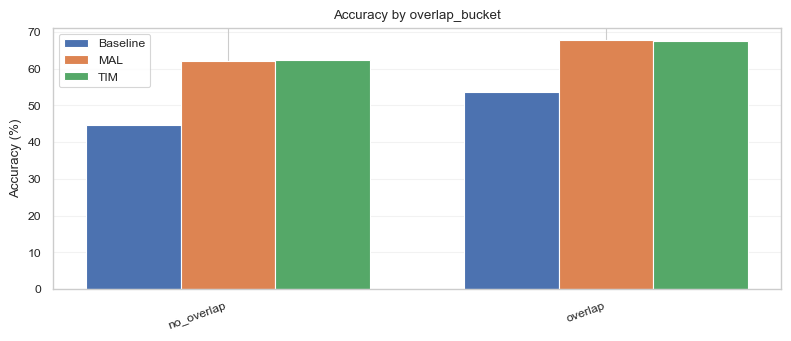

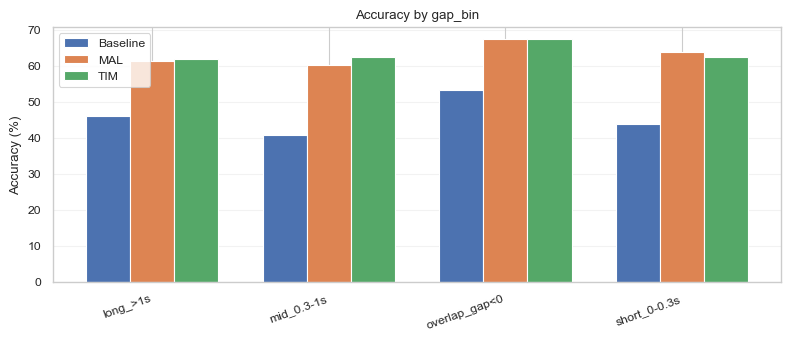

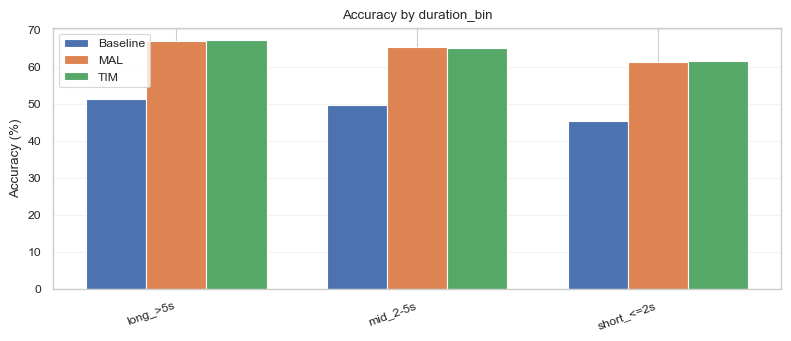

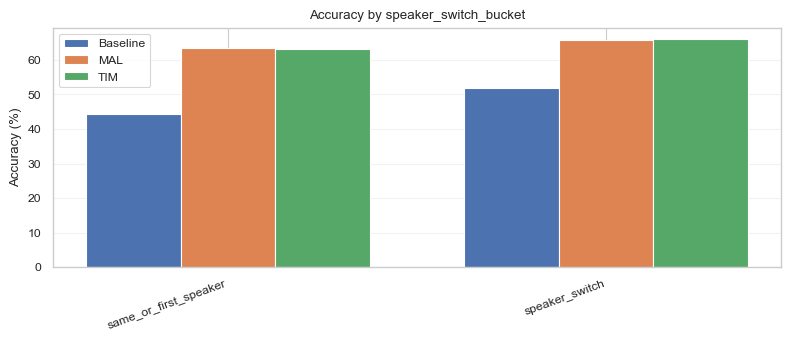

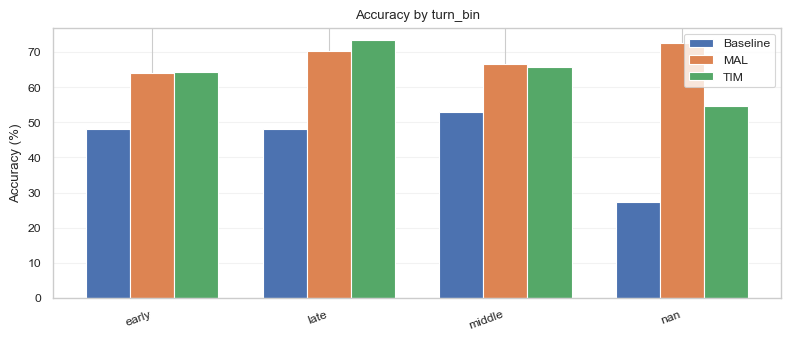

In [53]:
for bucket_col in ['overlap_bucket', 'gap_bin', 'duration_bin', 'speaker_switch_bucket', 'turn_bin']:
    plot_df = bucket_tables[bucket_tables['bucket_type'].eq(bucket_col)].copy()
    if plot_df.empty:
        continue
    plot_df = plot_df.sort_values('bucket')
    fig, ax = plt.subplots(figsize=(8, 3.5))
    x = np.arange(len(plot_df))
    width = 0.25
    ax.bar(x - width, plot_df['Baseline_acc_pct'], width, label='Baseline')
    ax.bar(x, plot_df['MAL_acc_pct'], width, label='MAL')
    ax.bar(x + width, plot_df['TIM_acc_pct'], width, label='TIM')
    ax.set_xticks(x, plot_df['bucket'], rotation=20, ha='right')
    ax.set_ylabel('Accuracy (%)')
    ax.set_title(f'Accuracy by {bucket_col}')
    ax.legend()
    ax.grid(axis='y', alpha=0.25)
    fig.tight_layout()
    fig.savefig(ERROR_FIGURE_DIR / f'accuracy_by_{bucket_col}.png', dpi=180)
    plt.show()


### High-Confidence Wrong Cases

Các sample này hữu ích để nghe lại trên demo: model sai nhưng confidence cao, hoặc TIM làm hỏng case MAL đúng.


In [54]:
interesting_cases = wide.copy()
interesting_cases['case_type'] = np.select(
    [
        ~interesting_cases['Baseline_correct'] & interesting_cases['MAL_correct'] & interesting_cases['TIM_correct'],
        interesting_cases['Baseline_correct'] & ~interesting_cases['MAL_correct'] & ~interesting_cases['TIM_correct'],
        ~interesting_cases['MAL_correct'] & interesting_cases['TIM_correct'],
        interesting_cases['MAL_correct'] & ~interesting_cases['TIM_correct'],
        ~interesting_cases['Baseline_correct'] & ~interesting_cases['TIM_correct'],
    ],
    [
        'MAL_and_TIM_fix_Baseline',
        'MAL_and_TIM_break_Baseline',
        'TIM_fixes_MAL',
        'TIM_breaks_MAL',
        'Baseline_and_TIM_wrong',
    ],
    default='other',
)
interesting_cases['max_wrong_confidence'] = interesting_cases[['Baseline_confidence', 'MAL_confidence', 'TIM_confidence']].max(axis=1)
case_cols = [
    'case_type', 'session', 'dialogue_id', 'utterance_id', 'speaker_id', 'start_time', 'end_time',
    'gold_label', 'Baseline_pred', 'MAL_pred', 'TIM_pred',
    'Baseline_confidence', 'MAL_confidence', 'TIM_confidence', 'max_wrong_confidence',
    'duration', 'gap_prev', 'overlap_prev', 'is_overlap', 'speaker_switch', 'turn_index_norm',
]
interesting_sorted = interesting_cases[case_cols].sort_values(['case_type', 'max_wrong_confidence'], ascending=[True, False])
interesting_sorted.to_csv(ERROR_REPORT_DIR / 'interesting_error_cases_for_demo.csv', index=False)
display(interesting_sorted[interesting_sorted['case_type'].ne('other')].sort_values('max_wrong_confidence', ascending=False).head(30))


,case_type,session,dialogue_id,utterance_id,speaker_id,start_time,end_time,gold_label,Baseline_pred,MAL_pred,TIM_pred,Baseline_confidence,MAL_confidence,TIM_confidence,max_wrong_confidence,duration,gap_prev,overlap_prev,is_overlap,speaker_switch,turn_index_norm
764,MAL_and_TIM_fix_Baseline,Ses01,Ses01M_impro03,Ses01M_impro03_M007,Ses01_M,39.5775,47.6600,happy,angry,happy,happy,0.575170,0.999440,0.998492,0.999440,8.0825,-4.2025,4.2025,1.0,1.0,0.116071
601,MAL_and_TIM_fix_Baseline,Ses01,Ses01F_script03_1,Ses01F_script03_1_F029,Ses01_F,250.2200,262.4300,happy,angry,happy,happy,0.564569,0.998575,0.999380,0.999380,12.2100,4.3500,0.0000,0.0,1.0,0.267857
6678,MAL_and_TIM_fix_Baseline,Ses05,Ses05F_script03_1,Ses05F_script03_1_M033,Ses05_M,234.0400,242.0500,happy,angry,happy,happy,0.518904,0.977876,0.999210,0.999210,8.0100,0.7200,0.0000,0.0,0.0,0.382979
5884,Baseline_and_TIM_wrong,Ses05,Ses05F_impro01,Ses05F_impro01_M003,Ses05_M,34.1100,40.8800,neutral,angry,angry,angry,0.720127,0.973542,0.999163,0.999163,6.7700,-0.3500,0.3500,1.0,1.0,0.053191
968,MAL_and_TIM_fix_Baseline,Ses01,Ses01M_impro07,Ses01M_impro07_M003,Ses01_M,20.9200,34.3800,happy,angry,happy,happy,0.562254,0.999117,0.997243,0.999117,13.4600,0.2500,0.0000,0.0,0.0,0.044643
979,MAL_and_TIM_fix_Baseline,Ses01,Ses01M_impro07,Ses01M_impro07_M007,Ses01_M,54.6300,56.3100,happy,angry,happy,happy,0.589631,0.998980,0.996786,0.998980,1.6800,-2.8262,2.8262,1.0,1.0,0.142857
6835,MAL_and_TIM_fix_Baseline,Ses05,Ses05M_impro03,Ses05M_impro03_M012,Ses05_M,104.4300,111.7000,happy,angry,happy,happy,0.487843,0.993537,0.998963,0.998963,7.2700,-1.6400,1.6400,1.0,1.0,0.202128
602,MAL_and_TIM_fix_Baseline,Ses01,Ses01F_script03_1,Ses01F_script03_1_M036,Ses01_M,256.8500,262.0325,happy,angry,happy,happy,0.478370,0.998893,0.998695,0.998893,5.1825,-5.5800,5.5800,1.0,1.0,0.276786
985,Baseline_and_TIM_wrong,Ses01,Ses01M_impro07,Ses01M_impro07_F012,Ses01_F,68.6400,72.3500,neutral,happy,happy,happy,0.586409,0.998836,0.993739,0.998836,3.7100,-10.2600,10.2600,1.0,1.0,0.196429
6019,MAL_and_TIM_fix_Baseline,Ses05,Ses05F_impro03,Ses05F_impro03_F037,Ses05_F,167.6700,170.0600,happy,angry,happy,happy,0.560419,0.991393,0.998546,0.998546,2.3900,-0.5500,0.5500,1.0,1.0,0.468085


### Error Analysis Notes


In [55]:
notes = []
for _, row in pair_summary.sort_values(['pair', 'status']).iterrows():
    notes.append(f"{row['pair']} / {row['status']}: {int(row['count'])} ({row['ratio_pct']:.2f}%).")

# Compact class-level deltas.
for label, row in per_class_pivot.iterrows():
    notes.append(
        f"Class {label}: MAL-Baseline {row['MAL_minus_Baseline_pp']:.2f} pp, "
        f"TIM-MAL {row['TIM_minus_MAL_pp']:.2f} pp, TIM-Baseline {row['TIM_minus_Baseline_pp']:.2f} pp."
    )

# Highlight temporal groups where TIM has largest gains/losses vs MAL.
temporal_only = bucket_tables[bucket_tables['bucket_type'].isin(['overlap_bucket', 'gap_bin', 'duration_bin', 'speaker_switch_bucket', 'turn_bin'])].copy()
if not temporal_only.empty:
    best_temporal = temporal_only.sort_values('TIM_minus_MAL_pp', ascending=False).head(5)
    worst_temporal = temporal_only.sort_values('TIM_minus_MAL_pp').head(5)
    notes.append('Top TIM gains vs MAL by temporal bucket:')
    for _, row in best_temporal.iterrows():
        notes.append(f"  {row['bucket_type']}={row['bucket']}: {row['TIM_minus_MAL_pp']:.2f} pp, n={int(row['n'])}.")
    notes.append('Worst TIM drops vs MAL by temporal bucket:')
    for _, row in worst_temporal.iterrows():
        notes.append(f"  {row['bucket_type']}={row['bucket']}: {row['TIM_minus_MAL_pp']:.2f} pp, n={int(row['n'])}.")

newline = chr(10)
notes_text = newline.join(f'- {line}' for line in notes)
(ERROR_REPORT_DIR / 'error_analysis_notes.md').write_text('# Error Analysis Notes' + newline + newline + notes_text + newline, encoding='utf-8')
print(notes_text)


- MAL_vs_Baseline / MAL_breaks_Baseline: 757 (10.05%).
- MAL_vs_Baseline / MAL_fixes_Baseline: 1933 (25.67%).
- MAL_vs_Baseline / both_correct: 2967 (39.41%).
- MAL_vs_Baseline / both_wrong: 1872 (24.86%).
- TIM_vs_Baseline / TIM_breaks_Baseline: 847 (11.25%).
- TIM_vs_Baseline / TIM_fixes_Baseline: 2025 (26.90%).
- TIM_vs_Baseline / both_correct: 2877 (38.21%).
- TIM_vs_Baseline / both_wrong: 1780 (23.64%).
- TIM_vs_MAL / TIM_breaks_MAL: 514 (6.83%).
- TIM_vs_MAL / TIM_fixes_MAL: 516 (6.85%).
- TIM_vs_MAL / both_correct: 4386 (58.25%).
- TIM_vs_MAL / both_wrong: 2113 (28.06%).
- Class angry: MAL-Baseline -14.90 pp, TIM-MAL -3.01 pp, TIM-Baseline -17.91 pp.
- Class happy: MAL-Baseline 57.09 pp, TIM-MAL 4.59 pp, TIM-Baseline 61.68 pp.
- Class neutral: MAL-Baseline 19.61 pp, TIM-MAL 1.81 pp, TIM-Baseline 21.43 pp.
- Class sad: MAL-Baseline 25.44 pp, TIM-MAL -1.78 pp, TIM-Baseline 23.67 pp.
- Top TIM gains vs MAL by temporal bucket:
-   turn_bin=late: 3.00 pp, n=233.
-   gap_bin=mid_0.3-1